In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Palestine Tourism Recommendation System
## Content-Based Filtering using Cosine Similarity

**Project:** AI Travel Squad — AI Track Contribution  
**Approach:** Content-Based Filtering  
**Algorithm:** Cosine Similarity (via Scikit-learn)  
**Dataset:** `palestine_tourist_attractions_v2.csv` — 331 tourist places across Palestinian cities

---

### How It Works

The user enters their preferences (city, budget, trip type, age group, number of people).  
I convert both the user preferences and each place's features into vectors, then measure how similar the user's vector is to each place's vector using **cosine similarity**.  
The places with the highest similarity scores are returned as recommendations.

```
User Input  →  Feature Vector  →  Cosine Similarity  →  Top 5-10 Recommendations
```

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 2. Load and Explore the Dataset

In [ ]:
#df = pd.read_csv('/content/__palestine_tourist_dat_with_images - __palestine_tourist_dat_with_images.csv.csv')
df = pd.read_csv('/content/drive/MyDrive/__palestine_tourist_dat_with_images - __palestine_tourist_dat_with_images.csv.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (308, 17)
Columns: ['ID', 'Place_Name', 'type', 'City', 'Budget_Level', 'Age_Group', 'Trip_Type', 'Description', 'Latitude', 'Longitude', 'Coordinate_Source', 'Geocode_Status', 'Estimated_Cost_ILS', 'Place_Name_AR', 'Description_AR', 'Description_EN', 'Image_URL']


,ID,Place_Name,type,City,Budget_Level,Age_Group,Trip_Type,Description,Latitude,Longitude,Coordinate_Source,Geocode_Status,Estimated_Cost_ILS,Place_Name_AR,Description_AR,Description_EN,Image_URL
0,1,Mosque of 'Umar Ibn al-Khattab (Qalqilya),Religious,Qalqilya,Medium,All,Religious,The Mosque of Umar Ibn al-Khattab (Qalqilya) i...,32.190557,34.966009,OpenStreetMap Photon (city centroid fallback),City-level,55,مسجد عمر بن الخطاب,مسجد عمر بن الخطاب في قلقيلية مسجد محلي سمي با...,The Mosque of Umar Ibn al-Khattab (Qalqilya) i...,https://www.palestineremembered.com/GeoPoints/...
1,2,Al-Far'a Tower,Historic Old City,Tubas,Medium,All,Cultural,Al-Far'a Tower is a historic watchtower struct...,32.323439,35.369366,OpenStreetMap Photon (city centroid fallback),City-level,60,برج الفارعة,برج الفارعة هو برج مراقبة تاريخي في محافظة طوباس.,Al-Far'a Tower is a historic watchtower struct...,https://scontent.fjrs9-1.fna.fbcdn.net/v/t39.3...
2,3,Khirbet Keshda (Ruin),Archaeological,Tubas,Low,Youth,Adventure,Khirbet Keshda is an archaeological ruin site ...,32.323439,35.369366,OpenStreetMap Photon (city centroid fallback),City-level,10,خربة كشدة (أثار),خربة كشدة هي منطقة أثرية ومأهولة تقع إلى الجنو...,Khirbet Kashdah is an archaeological and inhab...,https://thisweekinpalestine.com/wp-content/upl...
3,4,Khirbet Aniun (Ruin),Archaeological,Tubas,Low,Youth,Adventure,Khirbet Aniun is an archaeological ruin site i...,32.323439,35.369366,OpenStreetMap Photon (city centroid fallback),City-level,15,خربة عنيون (أثار),خربة عينون (ويعتقد أن اسمها تحريف للاسم السريا...,The site features rich historical layering; it...,https://wafa.ps/image/NewsThumbImg/Default/4b2...
4,5,Umm Burj,Archaeological,Tubas,Low,Youth,Adventure,"Khirbat Um Kubiesh, near 'Atuf in the Tubas go...",32.323439,35.369366,OpenStreetMap Photon (city centroid fallback),City-level,5,قرية خربة ام برج المهجرة,قرية أم برج، هي إحدى القرى الفلسطينية المهجرة ...,"Khirbat Um Kubiesh, near 'Atuf in the Tubas go...",https://pal48.ps/images/articles/497/101731102...


In [ ]:
df.loc[df["Trip_Type"] == "Educational", "City"].unique()

array(['Nablus', 'Ramallah'], dtype=object)

In [ ]:
df.loc[
    (df["Trip_Type"] == "Educational") &
    (df["City"].isin(["Nablus", "Ramallah"])),
    ["Place_Name", "City"]
]

,Place_Name,City
234,An-Najah National University,Nablus
252,Birzeit University,Ramallah


In [ ]:
educational_places = df.loc[
    (df["Trip_Type"] == "Educational") &
    (df["City"].isin(["Nablus", "Ramallah"])),
    ["Place_Name", "City", "Estimated_Cost_ILS"]
].sort_values("City")

print(educational_places.to_string(index=False))

                  Place_Name     City  Estimated_Cost_ILS
An-Najah National University   Nablus                 130
          Birzeit University Ramallah                  55


In [ ]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

print()
print('Data types:')
print(df.dtypes)

Missing values:
ID                    0
Place_Name            0
type                  0
City                  0
Budget_Level          0
Age_Group             0
Trip_Type             0
Description           0
Latitude              0
Longitude             0
Coordinate_Source     0
Geocode_Status        0
Estimated_Cost_ILS    0
Place_Name_AR         0
Description_AR        0
Description_EN        0
Image_URL             1
dtype: int64

Data types:
ID                      int64
Place_Name             object
type                   object
City                   object
Budget_Level           object
Age_Group              object
Trip_Type              object
Description            object
Latitude              float64
Longitude             float64
Coordinate_Source      object
Geocode_Status         object
Estimated_Cost_ILS      int64
Place_Name_AR          object
Description_AR         object
Description_EN         object
Image_URL              object
dtype: object


In [ ]:
# Unique values in each categorical feature
categorical_cols = ['type', 'City', 'Age_Group', 'Trip_Type','Estimated_Cost_ILS'] # 'Budget_Level',

for col in categorical_cols:
    print(f'{col}: {df[col].unique().tolist()}')

type: ['Religious', 'Historic Old City', 'Archaeological', 'Museum', 'Family/Recreational', 'Nature & Trails', 'Education', 'Historic', 'Cultural']
City: ['Qalqilya', 'Tubas', 'Jenin', 'Tulkarm', 'Nablus', 'Jerusalem', 'Bethlehem', 'Jericho', 'Hebron', 'Ramallah']
Age_Group: ['All', 'Youth', 'Family']
Trip_Type: ['Religious', 'Cultural', 'Adventure', 'Family', 'Relaxing', 'Educational']
Estimated_Cost_ILS: [55, 60, 10, 15, 5, 0, 30, 25, 35, 40, 115, 20, 145, 50, 95, 135, 45, 110, 105, 130, 70, 85]


### 2.1 Quick Visual Overview

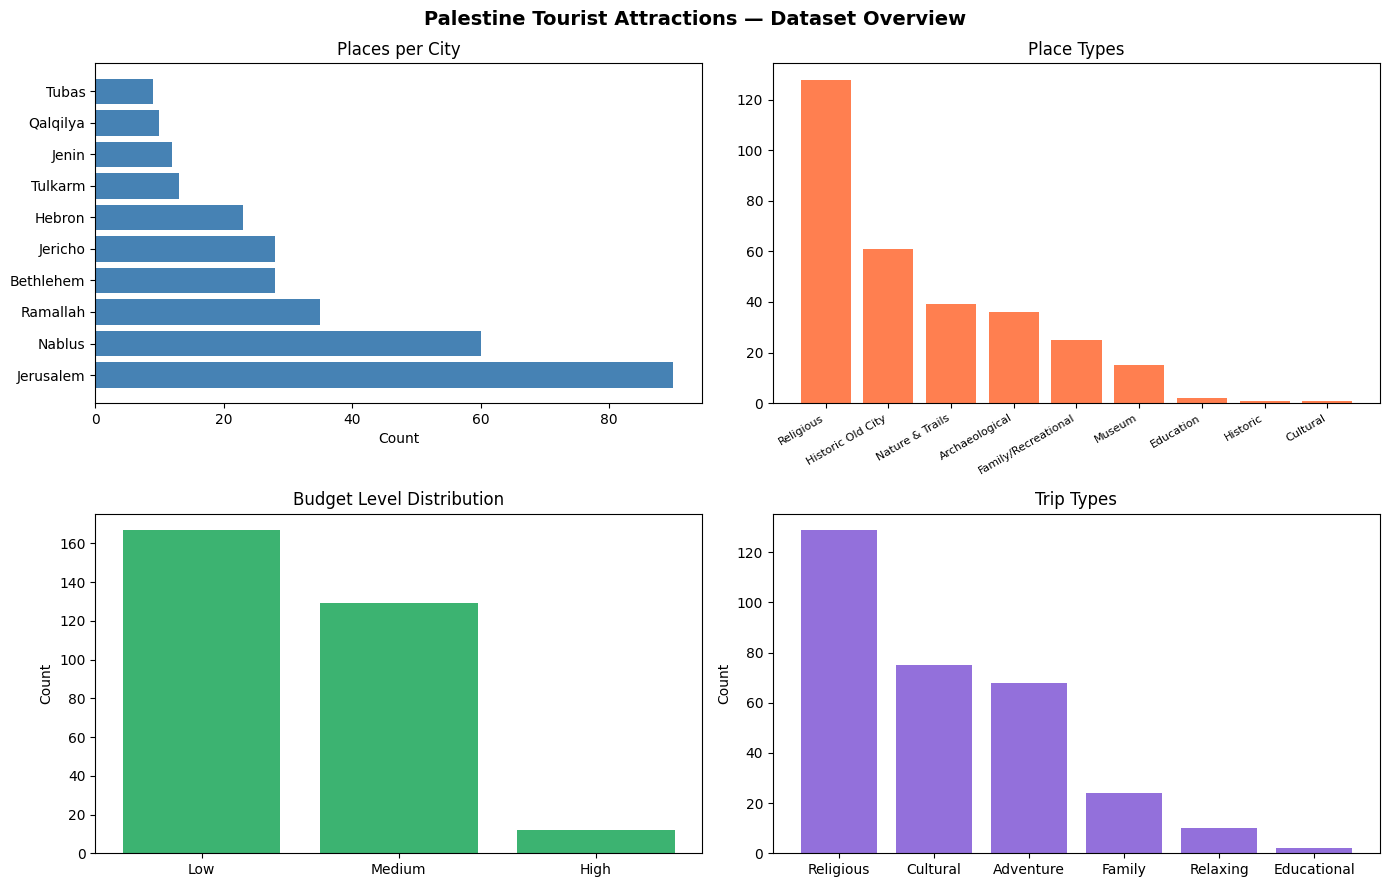

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Palestine Tourist Attractions — Dataset Overview', fontsize=14, fontweight='bold')

# Places per city
city_counts = df['City'].value_counts()
axes[0, 0].barh(city_counts.index, city_counts.values, color='steelblue')
axes[0, 0].set_title('Places per City')
axes[0, 0].set_xlabel('Count')

# Place types
type_counts = df['type'].value_counts()
axes[0, 1].bar(range(len(type_counts)), type_counts.values, color='coral')
axes[0, 1].set_xticks(range(len(type_counts)))
axes[0, 1].set_xticklabels(type_counts.index, rotation=30, ha='right', fontsize=8)
axes[0, 1].set_title('Place Types')

# Budget levels
budget_counts = df['Budget_Level'].value_counts()
axes[1, 0].bar(budget_counts.index, budget_counts.values, color='mediumseagreen')
axes[1, 0].set_title('Budget Level Distribution')
axes[1, 0].set_ylabel('Count')

# Trip types
trip_counts = df['Trip_Type'].value_counts()
axes[1, 1].bar(trip_counts.index, trip_counts.values, color='mediumpurple')
axes[1, 1].set_title('Trip Types')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Inspect Unique Values for User Input Features - Asala

In [ ]:
columns = [
    "City",
    "type",
    "Budget_Level",
    "Age_Group",
    "Trip_Type"
]

for col in columns:
    print(f"\n### {col}")
    print(df[col].dropna().unique())


### City
['Qalqilya' 'Tubas' 'Jenin' 'Tulkarm' 'Nablus' 'Jerusalem' 'Bethlehem'
 'Jericho' 'Hebron' 'Ramallah']

### type
['Religious' 'Historic Old City' 'Archaeological' 'Museum'
 'Family/Recreational' 'Nature & Trails' 'Education' 'Historic' 'Cultural']

### Budget_Level
['Medium' 'Low' 'High']

### Age_Group
['All' 'Youth' 'Family']

### Trip_Type
['Religious' 'Cultural' 'Adventure' 'Family' 'Relaxing' 'Educational']


In [ ]:
CITY_MAP = {
    "قلقيلية": "Qalqilya",
    "طوباس": "Tubas",
    "جنين": "Jenin",
    "طولكرم": "Tulkarm",
    "نابلس": "Nablus",
    "القدس": "Jerusalem",
    "بيت لحم": "Bethlehem",
    "أريحا": "Jericho",
    "الخليل": "Hebron",
    "رام الله": "Ramallah"
}

TYPE_MAP = {
    "ديني": "Religious",
    "المدينة القديمة التاريخية": "Historic Old City",
    "أثري": "Archaeological",
    "متحف": "Museum",
    "عائلي / ترفيهي": "Family/Recreational",
    "طبيعة ومسارات": "Nature & Trails",
    "تعليمي": "Education",
    "تاريخي": "Historic",
    "ثقافي": "Cultural"
}

BUDGET_MAP = {
    "منخفض": "Low",
    "متوسط": "Medium",
    "مرتفع": "High"
}

AGE_MAP = {
    "الجميع": "All",
    "شباب": "Youth",
    "عائلة": "Family"
}

TRIP_TYPE_MAP = {
    "ديني": "Religious",
    "ثقافي": "Cultural",
    "مغامرة": "Adventure",
    "عائلي": "Family",
    "استرخاء": "Relaxing",
    "تعليمي": "Educational"
}

### Convert user input from Arabic to English

In [ ]:
# def translate_user_input(cities_ar, trip_types_ar):
#     cities_en = [CITY_MAP[city] for city in cities_ar]
#     trip_types_en = [TRIP_TYPE_MAP[trip] for trip in trip_types_ar]

#     return cities_en, trip_types_en  # تنسيش تنحذف

In [ ]:
def translate_user_input(
    cities_ar,
    trip_types_ar,
    ages_ar
):
    cities_en = [
        CITY_MAP[city]
        for city in cities_ar
    ]

    trip_types_en = [
        TRIP_TYPE_MAP[trip]
        for trip in trip_types_ar
    ]

    ages_en = [
        AGE_MAP[age]
        for age in ages_ar
    ]

    return (
        cities_en,
        trip_types_en,
        ages_en
    )

## 3. Feature Engineering

I need to convert the categorical columns into a numeric format that the cosine similarity function can work with.

**Method: One-Hot Encoding**  
Each category becomes its own binary column (0 or 1). For example, `City = Nablus` becomes `City_Nablus = 1` and all other city columns = 0.

**Columns used:**
| Column | Role |
|--------|------|
| `type` | What kind of place it is |
| `City` | Which city it's in |
| `Budget_Level` | Cost range |
| `Age_Group` | Who it suits |
| `Trip_Type` | What kind of experience |

In [ ]:
feature_cols = [
    'type',
    'City',
    'Budget_Level',
    'Age_Group',
    'Trip_Type'
]

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

feature_matrix = encoder.fit_transform(
    df[feature_cols]
)

print(f'Feature matrix shape: {feature_matrix.shape}')

print(
    f'→ {df.shape[0]} places × '
    f'{feature_matrix.shape[1]} features'
)

print()

print('Features after encoding:')

for name in encoder.get_feature_names_out(feature_cols):
    print(f'  {name}')

Feature matrix shape: (308, 31)
→ 308 places × 31 features

Features after encoding:
  type_Archaeological
  type_Cultural
  type_Education
  type_Family/Recreational
  type_Historic
  type_Historic Old City
  type_Museum
  type_Nature & Trails
  type_Religious
  City_Bethlehem
  City_Hebron
  City_Jenin
  City_Jericho
  City_Jerusalem
  City_Nablus
  City_Qalqilya
  City_Ramallah
  City_Tubas
  City_Tulkarm
  Budget_Level_High
  Budget_Level_Low
  Budget_Level_Medium
  Age_Group_All
  Age_Group_Family
  Age_Group_Youth
  Trip_Type_Adventure
  Trip_Type_Cultural
  Trip_Type_Educational
  Trip_Type_Family
  Trip_Type_Relaxing
  Trip_Type_Religious


### What Does the Feature Matrix Look Like?

Each row is a place, each column is a one-hot encoded feature.  
A `1` means the place has that feature, `0` means it doesn't.

In [ ]:
# Show first 5 rows as a readable DataFrame
feature_df = pd.DataFrame(
    feature_matrix[:5],
    columns=encoder.get_feature_names_out(feature_cols),
    index=df['Place_Name'][:5]
)

# Only show columns with at least one 1 in first 5 rows
feature_df = feature_df.loc[:, (feature_df == 1).any()]
feature_df

,type_Archaeological,type_Historic Old City,type_Religious,City_Qalqilya,City_Tubas,Budget_Level_Low,Budget_Level_Medium,Age_Group_All,Age_Group_Youth,Trip_Type_Adventure,Trip_Type_Cultural,Trip_Type_Religious
Place_Name,,,,,,,,,,,,
Mosque of 'Umar Ibn al-Khattab (Qalqilya),0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Al-Far'a Tower,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
Khirbet Keshda (Ruin),1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
Khirbet Aniun (Ruin),1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
Umm Burj,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
TRIP_TYPE_TO_PLACE_TYPE = {
    'Religious': 'Religious',
    'Cultural': 'Historic Old City',
    'Adventure': 'Nature & Trails',
    'Family': 'Family/Recreational',
    'Relaxing': 'Nature & Trails',
    'Educational': 'Museum'
}

### Building a multi-choice user profile

In [ ]:
def create_user_profile(
    cities,
    budget,
    ages,
    trip_types,
    encoder
):
    feature_names = encoder.get_feature_names_out(feature_cols)
    user_vector = np.zeros(len(feature_names))

    # Cities
    for city in cities:
        feature = f"City_{city}"
        if feature in feature_names:
            user_vector[np.where(feature_names == feature)[0][0]] = 1

    # Budget
    for budget_level in budget:
        feature = f"Budget_Level_{budget_level}"
        if feature in feature_names:
            user_vector[np.where(feature_names == feature)[0][0]] = 1

    # Age Group
    for age in ages:
        feature = f"Age_Group_{age}"
        if feature in feature_names:
            user_vector[np.where(feature_names == feature)[0][0]] = 1

    # Trip Types
    for trip_type in trip_types:
        feature = f"Trip_Type_{trip_type}"
        if feature in feature_names:
            user_vector[np.where(feature_names == feature)[0][0]] = 1

    # Inferred Place Types
    for trip_type in trip_types:
        place_type = TRIP_TYPE_TO_PLACE_TYPE.get(trip_type)

        if place_type:
            feature = f"type_{place_type}"
            if feature in feature_names:
                user_vector[np.where(feature_names == feature)[0][0]] = 1

    return user_vector

## 4. Building the Recommendation Model

### How Cosine Similarity Works

Cosine similarity measures the angle between two vectors. If two vectors point in the same direction (same features), the angle is 0° and cosine = **1.0** (perfect match). If they point in completely different directions, cosine = **0.0** (no match).

```
similarity = (A · B) / (||A|| × ||B||)
```

- Result of **1.0** → the place matches the user's preferences perfectly  
- Result of **0.0** → the place has nothing in common with what the user wants

### Trip Type → Place Type Mapping

The dataset uses `type` (place category) and `Trip_Type` (experience category) as separate columns. I map each trip type to the most relevant place type so the user doesn't have to choose both manually.

In [ ]:
# TRIP_TYPE_TO_PLACE_TYPE = {
#     'Religious':   'Religious',
#     'Cultural':    'Historic Old City',
#     'Adventure':   'Nature & Trails',
#     'Family':      'Family/Recreational',
#     'Relaxing':    'Nature & Trails',
#     'Educational': 'Museum'
# }

# print('Trip Type → Inferred Place Type mapping:')
# for trip, place in TRIP_TYPE_TO_PLACE_TYPE.items():
#     print(f'  {trip:15} → {place}')

Now I put everything together in one function that takes the user's preferences,
builds their vector, computes similarity against all 331 places, and returns
the top N matches ranked by score.

In [ ]:
def apply_mmr(
    result_df,
    feature_matrix,
    top_n=10,
    lambda_param=0.7
):
    """
    Apply Maximal Marginal Relevance (MMR)
    to balance relevance and diversity.
    """

    if result_df.empty:
        return result_df

    # Original indices of the filtered candidates
    candidate_indices = result_df.index.tolist()

    # Feature vectors of candidate places
    candidate_features = feature_matrix[candidate_indices]

    # Similarity between places
    item_similarity = cosine_similarity(candidate_features)

    selected_positions = []

    # Select the most relevant place first
    first_position = (
        result_df["Similarity_Score"]
        .values
        .argmax()
    )

    selected_positions.append(first_position)

    # Select remaining places using MMR
    while len(selected_positions) < min(top_n, len(result_df)):

        remaining_positions = [
            i
            for i in range(len(candidate_indices))
            if i not in selected_positions
        ]

        mmr_scores = {}

        for position in remaining_positions:

            # Relevance to the user's preferences
            relevance = result_df.iloc[position]["Similarity_Score"]

            # Similarity to already selected places
            max_similarity = max(
                item_similarity[position][selected_position]
                for selected_position in selected_positions
            )

            # MMR score
            mmr_score = (
                lambda_param * relevance
                - (1 - lambda_param) * max_similarity
            )

            mmr_scores[position] = mmr_score

        # Select the best MMR candidate
        next_position = max(
            mmr_scores,
            key=mmr_scores.get
        )

        selected_positions.append(next_position)

    return result_df.iloc[selected_positions]

In [ ]:
def get_recommendations(
    cities,
    ages,
    trip_types,
    total_budget,
    people_over_10,
    top_n=10
):

    # Build user profile
    user_vector = create_user_profile(
        cities,
        [],  # No budget input
        ages,
        trip_types,
        encoder
    )

    # Calculate cosine similarity
    similarities = cosine_similarity(
        user_vector.reshape(1, -1),
        feature_matrix
    )[0]

    # Copy dataset
    result_df = df.copy()

    # Calculate total cost
    result_df["Total_Cost_ILS"] = (
        result_df["Estimated_Cost_ILS"] * people_over_10
    )

    # Direct city match
    result_df["City_Match"] = (
        result_df["City"].isin(cities).astype(int)
    )

    # Direct trip type match
    result_df["Trip_Type_Match"] = (
        result_df["Trip_Type"].isin(trip_types).astype(int)
    )

    # Age match
    # "All" is suitable for every age group
    result_df["Age_Match"] = (
        result_df["Age_Group"].isin(ages)
        | (result_df["Age_Group"] == "All")
    ).astype(int)

    # Budget fit
    # Lower cost within the user's budget gets a higher score
    result_df["Budget_Fit"] = (
        1 - (
            result_df["Total_Cost_ILS"] / total_budget
        )
    ).clip(0, 1)

    # Final recommendation score
    result_df["Similarity_Score"] = (
        similarities * 0.50
        + result_df["City_Match"] * 0.20
        + result_df["Trip_Type_Match"] * 0.15
        + result_df["Age_Match"] * 0.05
        + result_df["Budget_Fit"] * 0.10
    )

    # Age filtering
    # If the user selects "All", all age groups are accepted.
    # Otherwise, both the selected age group and "All" are accepted.
    if "All" in ages:
        age_filter = result_df["Age_Group"].notna()
    else:
        age_filter = (
            result_df["Age_Group"].isin(ages)
            | (result_df["Age_Group"] == "All")
        )

    # Filter valid recommendations
    result_df = result_df[
        result_df["City"].isin(cities)
        & result_df["Trip_Type"].isin(trip_types)
        & age_filter
        & (result_df["Total_Cost_ILS"] <= total_budget)
    ]

    # Apply MMR
    result_df = apply_mmr(
        result_df=result_df,
        feature_matrix=feature_matrix,
        top_n=top_n,
        lambda_param=0.7
    )

    # Select final columns
    recommendations = (
        result_df[
            [
                "ID",
                "Place_Name_AR",
                "Description_AR",
                "City",
                "Budget_Level",
                "Age_Group",
                "Trip_Type",
                "Estimated_Cost_ILS",
                "Total_Cost_ILS",
                "Similarity_Score"
            ]
        ]
        .reset_index(drop=True)
    )

    recommendations.index += 1

    return recommendations

## 5. Testing the Model

I test with three different user profiles to confirm the model returns sensible, varied results.

### Test 1 — Adventure seeker in Nablus (Youth, Low budget)

In [ ]:
# r1 = get_recommendations(
#     city='Nablus',
#     budget_level='Low',
#     trip_type='Adventure',
#     age_group='Youth',
#     num_people=3,
#     top_n=8
# )

# r1[['Place_Name', 'type', 'City', 'Estimated_Cost_ILS', 'Total_Cost_ILS', 'Similarity_Score']]

In [ ]:
# r1 = get_recommendations(
#     cities=["Nablus", "Tubas"],
#     trip_types=["Adventure", "Cultural"],
#     total_budget=300,
#     people_over_10=3,
#     top_n=8
# )

# r1[['Place_Name', 'type', 'City',
#     'Estimated_Cost_ILS', 'Total_Cost_ILS',
#     'Similarity_Score']]

### Test 1 — Two cities + two types of trips

In [ ]:
r1 = get_recommendations(
    cities=["Nablus", "Tubas"],
    ages=["Youth"],
    trip_types=["Adventure", "Cultural"],
    total_budget=300,
    people_over_10=3,
    top_n=8
)

r1

,ID,Place_Name_AR,Description_AR,City,Budget_Level,Age_Group,Trip_Type,Estimated_Cost_ILS,Total_Cost_ILS,Similarity_Score
1,87,جبل جرزيم والطائفة السامرية,جبل جرزيم المطل على نابلس أقدس موقع في الديانة...,Nablus,Low,Youth,Adventure,5,15,0.833062
2,2,برج الفارعة,برج الفارعة هو برج مراقبة تاريخي في محافظة طوباس.,Tubas,Medium,All,Cultural,60,180,0.693546
3,106,خان التجار (سوق الأقمشة),خان التجار (سوق الأقمشة) سوق تجاري تاريخي من ا...,Nablus,Medium,Youth,Cultural,45,135,0.793062
4,9,خربة المالح (خربة),أثار المالح موقع أثري في منطقة غور الأردن بمحا...,Tubas,Low,Youth,Adventure,0,0,0.753546
5,99,زاوية الطوباني (زاوية الشيخ نظمي عقل),زاوية الطوباني في البلدة القديمة بنابلس معلم م...,Nablus,Low,All,Cultural,0,0,0.753546
6,54,المدرج الروماني في سبسطية,المدرج الروماني في سبسطية أحد أبرز المعالم الأ...,Nablus,Medium,Youth,Adventure,25,75,0.728546
7,53,الشارع الروماني ذو الأعمدة,الشارع الروماني ذو الأعمدة في سبسطية جادة محفو...,Nablus,Low,Youth,Adventure,5,15,0.748546
8,85,عين قاريون (نبع),عين قاريون نبع طبيعي قرب نابلس، ومتنزه ترفيهي ...,Nablus,Low,Youth,Adventure,10,30,0.828062


### Test 2 — Lower budget

In [ ]:
r2 = get_recommendations(
    cities=["Nablus", "Tubas"],
    ages=["Youth"],
    trip_types=["Adventure", "Cultural"],
    total_budget=50,
    people_over_10=3,
    top_n=8
)

r2

,ID,Place_Name_AR,Description_AR,City,Budget_Level,Age_Group,Trip_Type,Estimated_Cost_ILS,Total_Cost_ILS,Similarity_Score
1,87,جبل جرزيم والطائفة السامرية,جبل جرزيم المطل على نابلس أقدس موقع في الديانة...,Nablus,Low,Youth,Adventure,5,15,0.808062
2,99,زاوية الطوباني (زاوية الشيخ نظمي عقل),زاوية الطوباني في البلدة القديمة بنابلس معلم م...,Nablus,Low,All,Cultural,0,0,0.753546
3,9,خربة المالح (خربة),أثار المالح موقع أثري في منطقة غور الأردن بمحا...,Tubas,Low,Youth,Adventure,0,0,0.753546
4,53,الشارع الروماني ذو الأعمدة,الشارع الروماني ذو الأعمدة في سبسطية جادة محفو...,Nablus,Low,Youth,Adventure,5,15,0.723546
5,85,عين قاريون (نبع),عين قاريون نبع طبيعي قرب نابلس، ومتنزه ترفيهي ...,Nablus,Low,Youth,Adventure,10,30,0.778062
6,5,قرية خربة ام برج المهجرة,قرية أم برج، هي إحدى القرى الفلسطينية المهجرة ...,Tubas,Low,Youth,Adventure,5,15,0.723546
7,51,سبسطية,سبسطية قرب نابلس واحدة من أهم المواقع الأثرية ...,Nablus,Low,All,Cultural,5,15,0.723546
8,67,خان الوكالة,خان الوكالة خان تاريخي من العصر العثماني في ال...,Nablus,Low,All,Cultural,5,15,0.723546


### Test 3 — One city + one trip type

In [ ]:
r3 = get_recommendations(
    cities=["Bethlehem"],
    ages=["All"],
    trip_types=["Religious"],
    total_budget=200,
    people_over_10=2,
    top_n=5
)

r3

,ID,Place_Name_AR,Description_AR,City,Budget_Level,Age_Group,Trip_Type,Estimated_Cost_ILS,Total_Cost_ILS,Similarity_Score
1,199,دير مار الياس,دير قرب الخضر مرتبط بالنبي إلياس ومعلم مألوف ع...,Bethlehem,Low,All,Religious,0,0,0.947214
2,275,كنيسة المهد,بازيليكا مدرجة في قائمة اليونسكو للتراث العالم...,Bethlehem,Low,All,Religious,0,0,0.947214
3,277,كنيسة مغارة الحليب,كنيسة صغيرة ترتبط تقليدياً بالعائلة المقدسة، و...,Bethlehem,Low,All,Religious,0,0,0.947214
4,279,كنيسة حقل الرعاة الأرثوذكسية اليونانية,كنيسة ذات قبة في بيت ساحور ترتبط بالرعاة التور...,Bethlehem,Low,All,Religious,0,0,0.947214
5,288,دير القديس جاورجيوس، الخضر,مزار ودير مسيحي محلي مرتبط بتقاليد الخضر الدين...,Bethlehem,Low,All,Religious,0,0,0.947214


### Test 2 — Religious trip to Jerusalem (Medium budget, for all ages)

In [ ]:
# r2 = get_recommendations(
#     city='Jerusalem',
#     budget_level='Medium',
#     trip_type='Religious',
#     age_group='All',
#     num_people=2,
#     top_n=8
# )

# r2[['Place_Name', 'type', 'City', 'Estimated_Cost_ILS', 'Total_Cost_ILS', 'Similarity_Score']]

### Test 3 — Family cultural outing in Bethlehem (Medium budget)

In [ ]:
# r3 = get_recommendations(
#     city='Bethlehem',
#     budget_level='Medium',
#     trip_type='Cultural',
#     age_group='Family',
#     num_people=4,
#     top_n=8
# )

# r3[['Place_Name', 'type', 'City', 'Estimated_Cost_ILS', 'Total_Cost_ILS', 'Similarity_Score']]

### Input transformation function

In [ ]:
def prepare_user_input(
    cities_ar,
    ages_ar,
    trip_types_ar,
    total_budget,
    people_over_10
):

    # Translate Arabic to English
    cities_en, ages_en, trip_types_en = translate_user_input(
        cities_ar,
        ages_ar,
        trip_types_ar
    )

    # Validate budget
    if total_budget <= 0:
        raise ValueError("Total budget must be greater than 0.")

    # Validate number of people
    if people_over_10 <= 0:
        raise ValueError(
            "Number of people over 10 must be greater than 0."
        )

    return (
        cities_en,
        ages_en,
        trip_types_en,
        total_budget,
        people_over_10
    )

In [ ]:
cities_ar = ["نابلس", "طوباس",'جنين']

ages_ar = ["الجميع"]

trip_types_ar = ["مغامرة", "ثقافي"]

total_budget = 300

people_over_10 = 3

(
    cities_en,
    trip_types_en,
    ages_en,
    total_budget,
    people_over_10
) = prepare_user_input(
    cities_ar,
    trip_types_ar,
    ages_ar,
    total_budget,
    people_over_10
)

recommendations = get_recommendations(
    cities=cities_en,
    ages=ages_en,
    trip_types=trip_types_en,
    total_budget=total_budget,
    people_over_10=people_over_10,
    top_n=8
)

recommendations

,ID,Place_Name_AR,Description_AR,City,Budget_Level,Age_Group,Trip_Type,Estimated_Cost_ILS,Total_Cost_ILS,Similarity_Score
1,99,زاوية الطوباني (زاوية الشيخ نظمي عقل),زاوية الطوباني في البلدة القديمة بنابلس معلم م...,Nablus,Low,All,Cultural,0,0,0.816228
2,9,خربة المالح (خربة),أثار المالح موقع أثري في منطقة غور الأردن بمحا...,Tubas,Low,Youth,Adventure,0,0,0.608114
3,18,مقبرة شهداء الجيش العراقي,تكرّم مقبرة شهداء الجيش العراقي في جنين الجنود...,Jenin,Medium,All,Cultural,40,120,0.776228
4,86,منتزه سما نابلس,منتزه سما نابلس مساحة خضراء ترفيهية في نابلس ت...,Nablus,Low,Family,Adventure,20,60,0.667171
5,14,مدرسة فاطمة خاتون,مدرسة فاطمة خاتون مؤسسة تعليمية إسلامية تاريخي...,Jenin,Low,All,Cultural,10,30,0.806228
6,109,مصبنة البدر,مصبنة البدر في نابلس منشأة تاريخية لإنتاج صابو...,Nablus,Medium,All,Cultural,25,75,0.791228
7,2,برج الفارعة,برج الفارعة هو برج مراقبة تاريخي في محافظة طوباس.,Tubas,Medium,All,Cultural,60,180,0.756228
8,51,سبسطية,سبسطية قرب نابلس واحدة من أهم المواقع الأثرية ...,Nablus,Low,All,Cultural,5,15,0.811228


**evaluate_recommendations**

In [ ]:
# def evaluate_recommendations(city, budget_level, trip_type, age_group, num_people=1, top_n=10):
#     """
#     Returns recommendations with an extra column showing how many
#     of the user's preferences each place matches (out of 5).
#     """
#     place_type = TRIP_TYPE_TO_PLACE_TYPE.get(trip_type, 'Historic Old City')

#     results = get_recommendations(
#         city=city,
#         budget_level=budget_level,
#         trip_type=trip_type,
#         age_group=age_group,
#         num_people=num_people,
#         top_n=top_n,
#         verbose=False
#     ).copy()

#     results['Matching_Features'] = (
#         (results['City']         == city).astype(int) +
#         (results['type']         == place_type).astype(int) +
#         (results['Budget_Level'] == budget_level).astype(int) +
#         (results['Age_Group']    == age_group).astype(int) +
#         (results['Trip_Type']    == trip_type).astype(int)
#     )

#     return results
# eval_results = evaluate_recommendations(
#     city='Nablus',
#     budget_level='Low',
#     trip_type='Adventure',
#     age_group='Youth',
#     top_n=10
# )

# eval_results[['Place_Name', 'City', 'type', 'Similarity_Score', 'Matching_Features']]

In [ ]:
def evaluate_recommendations(
    cities,
    ages,
    trip_types,
    total_budget,
    people_over_10,
    top_n=10
):
    """
    Evaluates recommendations based on user preferences.
    """

    results = get_recommendations(
        cities=cities,
        ages=ages,
        trip_types=trip_types,
        total_budget=total_budget,
        people_over_10=people_over_10,
        top_n=top_n
    ).copy()

    # Check whether each recommendation matches
    results["City_Match"] = (
        results["City"].isin(cities).astype(int)
    )

    results["Age_Match"] = (
        results["Age_Group"].isin(ages).astype(int)
    )

    results["Trip_Type_Match"] = (
        results["Trip_Type"].isin(trip_types).astype(int)
    )

    results["Budget_Match"] = (
        results["Total_Cost_ILS"] <= total_budget
    ).astype(int)

    # Number of matched criteria out of 4
    results["Matching_Features"] = (
        results["City_Match"] +
        results["Age_Match"] +
        results["Trip_Type_Match"] +
        results["Budget_Match"]
    )

    return results

In [ ]:
eval_results = evaluate_recommendations(
    cities=["Nablus", "Tubas"],
    ages=["Youth"],
    trip_types=["Adventure", "Cultural"],
    total_budget=300,
    people_over_10=3,
    top_n=8
)

eval_results[
    [
        'Place_Name_AR',
        'Description_AR',
        'City',
        'Age_Group',
        'Trip_Type',
        'Estimated_Cost_ILS',
        'Total_Cost_ILS',
        'Similarity_Score',
        'Matching_Features'
    ]
]

,Place_Name_AR,Description_AR,City,Age_Group,Trip_Type,Estimated_Cost_ILS,Total_Cost_ILS,Similarity_Score,Matching_Features
1,جبل جرزيم والطائفة السامرية,جبل جرزيم المطل على نابلس أقدس موقع في الديانة...,Nablus,Youth,Adventure,5,15,0.833062,4
2,برج الفارعة,برج الفارعة هو برج مراقبة تاريخي في محافظة طوباس.,Tubas,All,Cultural,60,180,0.693546,3
3,خان التجار (سوق الأقمشة),خان التجار (سوق الأقمشة) سوق تجاري تاريخي من ا...,Nablus,Youth,Cultural,45,135,0.793062,4
4,خربة المالح (خربة),أثار المالح موقع أثري في منطقة غور الأردن بمحا...,Tubas,Youth,Adventure,0,0,0.753546,4
5,زاوية الطوباني (زاوية الشيخ نظمي عقل),زاوية الطوباني في البلدة القديمة بنابلس معلم م...,Nablus,All,Cultural,0,0,0.753546,3
6,المدرج الروماني في سبسطية,المدرج الروماني في سبسطية أحد أبرز المعالم الأ...,Nablus,Youth,Adventure,25,75,0.728546,4
7,الشارع الروماني ذو الأعمدة,الشارع الروماني ذو الأعمدة في سبسطية جادة محفو...,Nablus,Youth,Adventure,5,15,0.748546,4
8,عين قاريون (نبع),عين قاريون نبع طبيعي قرب نابلس، ومتنزه ترفيهي ...,Nablus,Youth,Adventure,10,30,0.828062,4


## 6. Similarity Score Distribution

Here I visualize how similarity scores are spread across all 331 places for a sample user profile. This helps us understand whether the model differentiates well between matching and non-matching places.

In [ ]:
# # Compute similarity scores for Test 1 profile (across all places)
# sample_user = {
#     'type': 'Nature & Trails',
#     'City': 'Nablus',
#     'Budget_Level': 'Low',
#     'Age_Group': 'Youth',
#     'Trip_Type': 'Adventure'
# }

# user_vector = encoder.transform(pd.DataFrame([sample_user]))
# scores = cosine_similarity(user_vector, feature_matrix)[0]

# fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# fig.suptitle(
#     'Similarity Score Distribution\n'
#     'Profile: Nablus | Low Budget | Adventure | Youth',
#     fontsize=12
# )

# # Histogram
# axes[0].hist(scores, bins=20, color='steelblue', edgecolor='white')
# axes[0].set_xlabel('Cosine Similarity Score')
# axes[0].set_ylabel('Number of Places')
# axes[0].set_title('Score Distribution (all 331 places)')
# axes[0].axvline(np.mean(scores), color='red', linestyle='--',
#                 label=f'Mean = {np.mean(scores):.3f}')
# axes[0].legend()

# # Top 10 scores
# top_idx  = np.argsort(scores)[::-1][:10]
# top_names = df['Place_Name'].iloc[top_idx].str[:30]
# top_scores = scores[top_idx]

# axes[1].barh(range(10), top_scores[::-1], color='coral')
# axes[1].set_yticks(range(10))
# axes[1].set_yticklabels(top_names[::-1].values, fontsize=8)
# axes[1].set_xlabel('Similarity Score')
# axes[1].set_title('Top 10 Recommended Places')
# axes[1].set_xlim(0, 1.15)

# plt.tight_layout()
# plt.savefig('similarity_distribution.png', dpi=150, bbox_inches='tight')
# plt.show()

### Recommendation Score Distribution

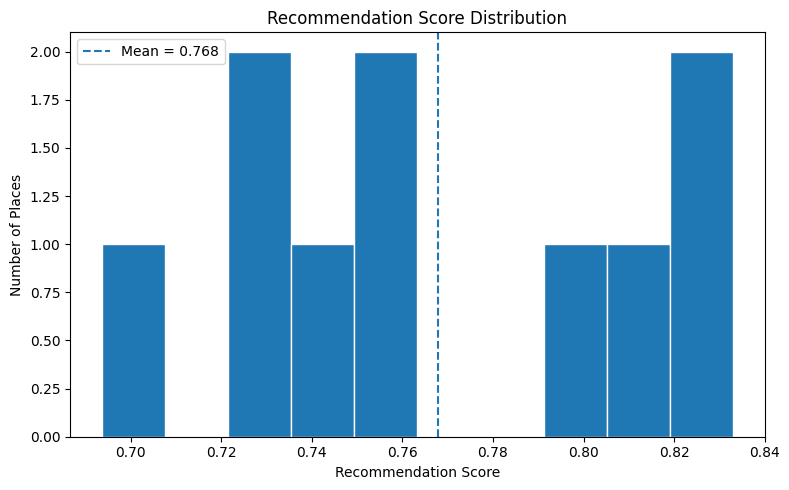

In [ ]:
import matplotlib.pyplot as plt

# Get recommendations
r1 = get_recommendations(
    cities=["Nablus", "Tubas"],
    ages=["Youth"],
    trip_types=["Adventure", "Cultural"],
    total_budget=300,
    people_over_10=3,
    top_n=10
)

# Plot Recommendation Score Distribution
plt.figure(figsize=(8, 5))

plt.hist(
    r1["Similarity_Score"],
    bins=10,
    edgecolor="white"
)

plt.xlabel("Recommendation Score")
plt.ylabel("Number of Places")
plt.title("Recommendation Score Distribution")

plt.axvline(
    r1["Similarity_Score"].mean(),
    linestyle="--",
    label=f"Mean = {r1['Similarity_Score'].mean():.3f}"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "recommendation_score_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 7. Export the Model for Backend Integration

The backend team can load these two files and call `cosine_similarity()` directly — no need to re-fit the encoder.

In [ ]:
# # Save the encoder (fitted on training data)
# joblib.dump(encoder, 'tourism_encoder.pkl')

# # Save the pre-computed feature matrix (all 331 places already encoded)
# np.save('feature_matrix.npy', feature_matrix)

# print('Exported:')
# print('  tourism_encoder.pkl   → OneHotEncoder fitted on all 331 places')
# print('  feature_matrix.npy   → Pre-computed feature matrix (331 × 31)')
# print()
# print('Usage in backend (Python):')
# print("  encoder        = joblib.load('tourism_encoder.pkl')")
# print("  feature_matrix = np.load('feature_matrix.npy')")
# print("  # Then call get_recommendations(...)")

In [ ]:
# # Verify: reload encoder and reproduce Test 1 results
# encoder_loaded = joblib.load('tourism_encoder.pkl')
# matrix_loaded  = np.load('feature_matrix.npy')

# sample_user = pd.DataFrame([{
#     'type': 'Nature & Trails',
#     'City': 'Nablus',
#     'Budget_Level': 'Low',
#     'Age_Group': 'Youth',
#     'Trip_Type': 'Adventure'
# }])

# v = encoder_loaded.transform(sample_user)
# s = cosine_similarity(v, matrix_loaded)[0]

# top5 = df.copy()
# top5['score'] = s
# top5 = top5.nlargest(5, 'score')[['Place_Name', 'City', 'score']]
# top5.index = range(1, 6)

# print('Verification — same results after reload:')
# print(top5.to_string())

## 8. Summary

### What I Built

A content-based recommendation system for Palestinian tourism using **Cosine Similarity** and **One-Hot Encoding** to recommend tourist places based on user preferences.

### Technical Details

| **Item**            | **Value**                                                  |
| ------------------- | ---------------------------------------------------------- |
| Algorithm           | Cosine Similarity                                          |
| Encoding            | One-Hot Encoding (`OneHotEncoder`)                         |
| Feature matrix size | 308 places × 17 features                                   |
| Features used       | type, City, Budget_Level, Age_Group, Trip_Type             |
| User inputs         | City, Total Budget, Trip Type, Age Group, Number of People |
| Budget Level        | Dataset attribute used to order recommendations            |
| Output              | Top 5–10 recommended places with similarity scores         |

### How the Score Is Interpreted

* **Higher score** → Stronger overall match with the user's preferences
* **Lower score** → Weaker match with the user's preferences
* The score is based on the encoded feature similarity and additional matching criteria.

> **Note:** A similarity score of `1.0` should not automatically be interpreted as "matches every user preference exactly"; it represents maximum cosine similarity between the encoded vectors.

### Files Exported for Backend

* `tourism_data.pkl` → tourism dataset
* `encoder.pkl` → fitted `OneHotEncoder`
* `feature_matrix.pkl` → pre-computed feature matrix
* `palestine_tourist_attractions_v2.csv` → original dataset

### Limitations & Future Improvements

* The dataset contains **308 tourist places**; adding more verified places could improve recommendation diversity.
* Adding **TF-IDF on `Description`** could capture richer semantic information about tourist attractions.
* User feedback and ratings could enable **collaborative filtering** in the future.
* A hybrid recommendation approach could combine content-based features with user behavior and semantic text similarity.
